In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
#creating dataframes using just closing prices like FRED's format'

sp500 = pd.read_csv('SP500.csv', usecols=['Date','Close'], index_col='Date').round({'Close':2})
sp500.index = pd.to_datetime(sp500.index)

dxy = pd.read_csv('DXY.csv', usecols=['Date','Close'], index_col='Date').round({'Close':2})
dxy.index = pd.to_datetime(dxy.index)

us02y = pd.read_csv('US02Y.csv', usecols=['Date','Close'], index_col='Date')
us02y.index = pd.to_datetime(us02y.index)

vix = pd.read_csv('VIX.csv', usecols=['Date','Close'], index_col='Date').round({'Close':2})
vix.index = pd.to_datetime(vix.index)

In [3]:
market_df = sp500.merge(dxy, left_index=True, right_index=True, how='inner')
market_df = market_df.merge(us02y, left_index=True, right_index=True, how='inner')
market_df = market_df.merge(vix, left_index=True, right_index=True, how='inner', suffixes=('_w','_z'))

market_df = market_df.rename(columns={
    'Close_x':'SP500',
    'Close_y':'DXY',
    'Close_w':'US02Y',
    'Close_z':'VIX'
})

market_df.head()


,SP500,DXY,US02Y,VIX
Date,,,,
1990-01-02,359.69,94.29,7.87,17.24
1990-01-03,358.76,94.42,7.94,18.19
1990-01-04,355.67,92.52,7.92,19.22
1990-01-05,352.20,92.85,7.90,20.11
1990-01-08,353.79,92.05,7.90,20.26


In [4]:
market_df.isna().sum()

SP500     0
DXY       0
US02Y    73
VIX       0
dtype: int64

In [5]:
market_df = market_df.dropna()
print(market_df.isna().sum())
print(market_df.shape)

SP500    0
DXY      0
US02Y    0
VIX      0
dtype: int64
(9111, 4)


In [6]:
#1 week = 5 closes
#1 month = 21 closes
#6 months = 126 closes
# 1 year = 252 closes

log_sp500 = np.log(market_df['SP500'])

market_df['fut_returns_5d'] = (log_sp500.shift(-5) - log_sp500).round(2)
market_df['fut_returns_21d'] = (log_sp500.shift(-21) - log_sp500).round(2)
market_df['fut_returns_126d'] = (log_sp500.shift(-126) - log_sp500).round(2)
market_df['fut_returns_252d'] = (log_sp500.shift(-252) - log_sp500).round(2)

market_df.head()


,SP500,DXY,US02Y,VIX,fut_returns_5d,fut_returns_21d,fut_returns_126d,fut_returns_252d
Date,,,,,,,,
1990-01-02,359.69,94.29,7.87,17.24,-0.03,-0.09,0.00,-0.11
1990-01-03,358.76,94.42,7.94,18.19,-0.03,-0.08,-0.01,-0.13
1990-01-04,355.67,92.52,7.92,19.22,-0.02,-0.07,0.01,-0.12
1990-01-05,352.20,92.85,7.90,20.11,-0.04,-0.07,0.02,-0.12
1990-01-08,353.79,92.05,7.90,20.26,-0.04,-0.06,0.01,-0.12


In [7]:
log_vix = np.log(market_df['VIX'])

market_df['delta_vix_5d'] = (log_vix - log_vix.shift(5)).round(2)
market_df['delta_vix_21d'] = (log_vix - log_vix.shift(21)).round(2)
market_df['delta_vix_126d'] = (log_vix - log_vix.shift(126)).round(2)
market_df['delta_vix_252d'] = (log_vix - log_vix.shift(252)).round(2)

log_dxy = np.log(market_df['DXY'])

market_df['delta_dxy_5d'] = (log_dxy - log_dxy.shift(5)).round(2)
market_df['delta_dxy_21d'] = (log_dxy - log_dxy.shift(21)).round(2)
market_df['delta_dxy_126d'] = (log_dxy - log_dxy.shift(126)).round(2)
market_df['delta_dxy_252d'] = (log_dxy - log_dxy.shift(252)).round(2)

market_df['delta_US02Y_5d'] = (market_df['US02Y'] - market_df['US02Y'].shift(5)).round(2)
market_df['delta_US02Y_21d'] = (market_df['US02Y'] - market_df['US02Y'].shift(21)).round(2)
market_df['delta_US02Y_126d'] = (market_df['US02Y'] - market_df['US02Y'].shift(126)).round(2)
market_df['delta_US02Y_252d'] = (market_df['US02Y'] - market_df['US02Y'].shift(252)).round(2)

market_df.head(10)

,SP500,DXY,US02Y,VIX,fut_returns_5d,fut_returns_21d,fut_returns_126d,fut_returns_252d,delta_vix_5d,delta_vix_21d,delta_vix_126d,delta_vix_252d,delta_dxy_5d,delta_dxy_21d,delta_dxy_126d,delta_dxy_252d,delta_US02Y_5d,delta_US02Y_21d,delta_US02Y_126d,delta_US02Y_252d
Date,,,,,,,,,,,,,,,,,,,,
1990-01-02,359.69,94.29,7.87,17.24,-0.03,-0.09,0.00,-0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03,358.76,94.42,7.94,18.19,-0.03,-0.08,-0.01,-0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04,355.67,92.52,7.92,19.22,-0.02,-0.07,0.01,-0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05,352.20,92.85,7.90,20.11,-0.04,-0.07,0.02,-0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08,353.79,92.05,7.90,20.26,-0.04,-0.06,0.01,-0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-09,349.62,92.35,7.91,22.20,-0.04,-0.05,0.03,-0.10,0.25,NaN,NaN,NaN,-0.02,NaN,NaN,NaN,0.04,NaN,NaN,NaN
1990-01-10,347.31,92.39,7.91,22.44,-0.03,-0.04,0.05,-0.11,0.21,NaN,NaN,NaN,-0.02,NaN,NaN,NaN,-0.03,NaN,NaN,NaN
1990-01-11,348.53,92.40,7.91,20.05,-0.03,-0.05,0.05,-0.11,0.04,NaN,NaN,NaN,-0.00,NaN,NaN,NaN,-0.01,NaN,NaN,NaN
1990-01-12,339.93,92.43,7.93,24.64,-0.03,-0.03,0.08,-0.07,0.20,NaN,NaN,NaN,-0.00,NaN,NaN,NaN,0.03,NaN,NaN,NaN


In [8]:
market_df = market_df.dropna()
market_df.shape

(8607, 20)

In [9]:
market_df.describe()
#returns following a gaussian distribuiton slightly positive assimetric
#5d = 0.18%
#21d = 0.72%
#126d = 4.2%
#252d = 8.46%

,SP500,DXY,US02Y,VIX,fut_returns_5d,fut_returns_21d,fut_returns_126d,fut_returns_252d,delta_vix_5d,delta_vix_21d,delta_vix_126d,delta_vix_252d,delta_dxy_5d,delta_dxy_21d,delta_dxy_126d,delta_dxy_252d,delta_US02Y_5d,delta_US02Y_21d,delta_US02Y_126d,delta_US02Y_252d
count,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000,8607.000000
mean,1789.384086,92.507725,3.093610,19.379054,0.001775,0.007151,0.042235,0.084629,-0.000123,-0.000569,-0.003187,-0.006189,0.000055,0.000448,0.002941,0.004540,-0.001871,-0.008118,-0.055618,-0.119138
std,1324.258246,10.235294,2.155515,7.864775,0.024002,0.046009,0.108258,0.160030,0.133983,0.218011,0.339977,0.393786,0.011604,0.023379,0.058400,0.078607,0.123143,0.264166,0.806748,1.301445
min,311.490000,71.330000,0.090000,9.140000,-0.200000,-0.400000,-0.630000,-0.680000,-0.630000,-0.840000,-1.200000,-1.400000,-0.080000,-0.100000,-0.150000,-0.200000,-1.120000,-1.230000,-2.790000,-3.620000
25%,963.065000,84.320000,0.890000,13.770000,-0.010000,-0.010000,-0.000000,0.030000,-0.080000,-0.130000,-0.220000,-0.250000,-0.010000,-0.010000,-0.040000,-0.050000,-0.060000,-0.140000,-0.480000,-1.000000
50%,1309.930000,92.650000,2.990000,17.500000,0.000000,0.010000,0.050000,0.110000,-0.010000,-0.020000,-0.030000,-0.020000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,-0.010000,-0.040000
75%,2182.430000,99.155000,4.910000,22.655000,0.010000,0.030000,0.110000,0.180000,0.070000,0.110000,0.180000,0.240000,0.010000,0.020000,0.040000,0.060000,0.060000,0.130000,0.390000,0.570000
max,6144.150000,120.900000,7.740000,82.690000,0.170000,0.220000,0.410000,0.560000,1.140000,1.770000,1.730000,1.820000,0.060000,0.120000,0.200000,0.230000,0.700000,1.050000,2.790000,4.260000


In [10]:
baseline = pd.DataFrame(market_df[['fut_returns_5d','fut_returns_21d','fut_returns_126d','fut_returns_252d']].describe())

baseline['sp_%_positive_periods_5d'] = (market_df['fut_returns_5d'] > 0).mean()
baseline['sp_%_positive_periods_21d'] = (market_df['fut_returns_21d'] > 0).mean()
baseline['sp_%_positive_periods_126d'] = (market_df['fut_returns_126d'] > 0).mean()
baseline['sp_%_positive_periods_252d'] = (market_df['fut_returns_252d'] > 0).mean()

baseline

#as long the observation period gets, more likely it is to get positive returns from sp500

,fut_returns_5d,fut_returns_21d,fut_returns_126d,fut_returns_252d,sp_%_positive_periods_5d,sp_%_positive_periods_21d,sp_%_positive_periods_126d,sp_%_positive_periods_252d
count,8607.000000,8607.000000,8607.000000,8607.000000,0.462995,0.586848,0.733124,0.794237
mean,0.001775,0.007151,0.042235,0.084629,0.462995,0.586848,0.733124,0.794237
std,0.024002,0.046009,0.108258,0.160030,0.462995,0.586848,0.733124,0.794237
min,-0.200000,-0.400000,-0.630000,-0.680000,0.462995,0.586848,0.733124,0.794237
25%,-0.010000,-0.010000,-0.000000,0.030000,0.462995,0.586848,0.733124,0.794237
50%,0.000000,0.010000,0.050000,0.110000,0.462995,0.586848,0.733124,0.794237
75%,0.010000,0.030000,0.110000,0.180000,0.462995,0.586848,0.733124,0.794237
max,0.170000,0.220000,0.410000,0.560000,0.462995,0.586848,0.733124,0.794237


In [11]:
windows = ['fut_returns_5d','fut_returns_21d','fut_returns_126d','fut_returns_252d']

def combination(dataframe, variable_column_1, variable_column_2, fut_returns):
    #DXY AND VIX UP
    quadrants = {
        'up_up' : (dataframe[variable_column_1] > 0) & (dataframe[variable_column_2] > 0),
        'up_down' : (dataframe[variable_column_1] > 0) & (dataframe[variable_column_2] < 0),
        'down_up' : (dataframe[variable_column_1] < 0) & (dataframe[variable_column_2] > 0),
        'down_down' : (dataframe[variable_column_1] < 0) & (dataframe[variable_column_2] < 0),
    }
    
    results = []
    for name, mask in quadrants.items():
        subset = dataframe.loc[mask, fut_returns]
        stats = (subset.describe()
                 .T
                 .assign(
                     pct_positive = (subset > 0).mean().values,
                     N=len(subset),
                     quadrant=name,
                     var1=variable_column_1,
                     var2=variable_column_2
                 ))
        results.append(stats)
    

    return pd.concat(results)

In [12]:
#DXY AND VIX
res_dxy_vix_5d = combination(market_df, 'delta_dxy_5d','delta_vix_5d',windows)

res_dxy_vix_21d = combination(market_df, 'delta_dxy_21d','delta_vix_21d',windows)

res_dxy_vix_126d = combination(market_df, 'delta_dxy_126d','delta_vix_126d', windows)

res_dxy_vix_252d = combination(market_df, 'delta_dxy_252d','delta_vix_252d', windows)

#DXY AND US02Y
res_dxy_us02y_5d = combination(market_df, 'delta_dxy_5d','delta_US02Y_5d',windows)

res_dxy_us02y_21d = combination(market_df, 'delta_dxy_21d','delta_US02Y_21d',windows)

res_dxy_us02y_126d = combination(market_df, 'delta_dxy_126d','delta_US02Y_126d',windows)

res_dxy_us02y_252d = combination(market_df, 'delta_dxy_252d','delta_US02Y_252d',windows)

#US02Y AND VIX
res_us02y_vix_5d = combination(market_df, 'delta_US02Y_5d','delta_vix_5d',windows)

res_us02y_vix_21d = combination(market_df, 'delta_US02Y_21d','delta_vix_21d',windows)

res_us02y_vix_126d = combination(market_df, 'delta_US02Y_126d','delta_vix_126d',windows)

res_us02y_vix_252d = combination(market_df, 'delta_US02Y_252d','delta_vix_252d',windows)

all_results = pd.concat([res_dxy_us02y_5d, res_dxy_us02y_21d, res_dxy_us02y_126d, res_dxy_us02y_252d,
                         res_dxy_vix_5d, res_dxy_vix_21d, res_dxy_vix_126d, res_dxy_vix_252d,
                         res_us02y_vix_5d, res_us02y_vix_21d, res_us02y_vix_126d, res_us02y_vix_252d])

all_results

,count,mean,std,min,25%,50%,75%,max,pct_positive,N,quadrant,var1,var2
fut_returns_5d,1526.0,0.001245,0.022404,-0.11,-0.01,0.00,0.01,0.12,0.435125,1526,up_up,delta_dxy_5d,delta_US02Y_5d
fut_returns_21d,1526.0,0.004803,0.044181,-0.34,-0.02,0.01,0.03,0.18,0.550459,1526,up_up,delta_dxy_5d,delta_US02Y_5d
fut_returns_126d,1526.0,0.033552,0.107377,-0.60,-0.01,0.05,0.09,0.34,0.709043,1526,up_up,delta_dxy_5d,delta_US02Y_5d
fut_returns_252d,1526.0,0.075950,0.148796,-0.55,0.02,0.10,0.17,0.50,0.779817,1526,up_up,delta_dxy_5d,delta_US02Y_5d
fut_returns_5d,1020.0,0.001980,0.030060,-0.20,-0.01,-0.00,0.02,0.17,0.468627,1020,up_down,delta_dxy_5d,delta_US02Y_5d
...,...,...,...,...,...,...,...,...,...,...,...,...,...
fut_returns_252d,2437.0,0.083906,0.224512,-0.68,0.03,0.15,0.22,0.56,0.763233,2437,down_up,delta_US02Y_252d,delta_vix_252d
fut_returns_5d,1982.0,0.001544,0.018721,-0.14,-0.01,0.00,0.01,0.07,0.446014,1982,down_down,delta_US02Y_252d,delta_vix_252d
fut_returns_21d,1982.0,0.003865,0.042893,-0.35,-0.01,0.01,0.03,0.11,0.565086,1982,down_down,delta_US02Y_252d,delta_vix_252d
fut_returns_126d,1982.0,0.021221,0.109062,-0.63,-0.02,0.04,0.09,0.24,0.692735,1982,down_down,delta_US02Y_252d,delta_vix_252d


In [13]:
lags = {
    'fut_returns_5d':5,
    'fut_returns_21d':21,
    'fut_returns_126d':126,
    'fut_returns_252d':252
}

#calculating significancy through newey-west
def significancy(all_results, dataframe, lags):
    sinais ={ 
        'up_up': lambda df, v1, v2: (df[v1] > 0) & (df[v2] > 0),
        'up_down': lambda df, v1, v2: (df[v1] > 0) & (df[v2] < 0),
        'down_up': lambda df, v1, v2: (df[v1] < 0) & (df[v2] > 0),
        'down_down': lambda df, v1, v2: (df[v1] < 0) & (df[v2] < 0),
    }

    all_results['t_stat'] = np.nan
    all_results['p_value'] = np.nan

    combinacoes = all_results[['var1','var2','quadrant']].drop_duplicates()

    for _, row in combinacoes.iterrows():
        var1 = row['var1']
        var2 = row['var2']
        quadrant = row['quadrant']

        mask = sinais[quadrant](dataframe,var1,var2)

        for horizonte, maxlags in lags.items():
            y = dataframe.loc[mask, horizonte].dropna()
            X = sm.add_constant(np.ones(len(y)))

            modelo = sm.OLS(y, X).fit(
                cov_type='HAC',
                cov_kwds={'maxlags':maxlags}
            )

            linha = (
                (all_results.index == horizonte) &
                (all_results['var1'] == var1) &
                (all_results['var2'] == var2) &
                (all_results['quadrant'] == quadrant)
            )

            all_results.loc[linha, 't_stat'] = modelo.tvalues.iloc[0]
            all_results.loc[linha, 'p_value'] = modelo.pvalues.iloc[0]
    
    return all_results

In [14]:
significancy(all_results, market_df, lags)

,count,mean,std,min,25%,50%,75%,max,pct_positive,N,quadrant,var1,var2,t_stat,p_value
fut_returns_5d,1526.0,0.001245,0.022404,-0.11,-0.01,0.00,0.01,0.12,0.435125,1526,up_up,delta_dxy_5d,delta_US02Y_5d,1.559864,0.118792
fut_returns_21d,1526.0,0.004803,0.044181,-0.34,-0.02,0.01,0.03,0.18,0.550459,1526,up_up,delta_dxy_5d,delta_US02Y_5d,2.018165,0.043574
fut_returns_126d,1526.0,0.033552,0.107377,-0.60,-0.01,0.05,0.09,0.34,0.709043,1526,up_up,delta_dxy_5d,delta_US02Y_5d,2.579452,0.009896
fut_returns_252d,1526.0,0.075950,0.148796,-0.55,0.02,0.10,0.17,0.50,0.779817,1526,up_up,delta_dxy_5d,delta_US02Y_5d,3.687276,0.000227
fut_returns_5d,1020.0,0.001980,0.030060,-0.20,-0.01,-0.00,0.02,0.17,0.468627,1020,up_down,delta_dxy_5d,delta_US02Y_5d,1.369713,0.170777
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fut_returns_252d,2437.0,0.083906,0.224512,-0.68,0.03,0.15,0.22,0.56,0.763233,2437,down_up,delta_US02Y_252d,delta_vix_252d,1.541019,0.123312
fut_returns_5d,1982.0,0.001544,0.018721,-0.14,-0.01,0.00,0.01,0.07,0.446014,1982,down_down,delta_US02Y_252d,delta_vix_252d,2.096850,0.036007
fut_returns_21d,1982.0,0.003865,0.042893,-0.35,-0.01,0.01,0.03,0.11,0.565086,1982,down_down,delta_US02Y_252d,delta_vix_252d,1.319207,0.187100
fut_returns_126d,1982.0,0.021221,0.109062,-0.63,-0.02,0.04,0.09,0.24,0.692735,1982,down_down,delta_US02Y_252d,delta_vix_252d,1.299478,0.193780


In [15]:
all_results['significant'] = all_results['p_value'] < 0.05
print(all_results['significant'].sum(), "out of", len(all_results), "significant results")
all_results

128 out of 192 significant results


,count,mean,std,min,25%,50%,75%,max,pct_positive,N,quadrant,var1,var2,t_stat,p_value,significant
fut_returns_5d,1526.0,0.001245,0.022404,-0.11,-0.01,0.00,0.01,0.12,0.435125,1526,up_up,delta_dxy_5d,delta_US02Y_5d,1.559864,0.118792,False
fut_returns_21d,1526.0,0.004803,0.044181,-0.34,-0.02,0.01,0.03,0.18,0.550459,1526,up_up,delta_dxy_5d,delta_US02Y_5d,2.018165,0.043574,True
fut_returns_126d,1526.0,0.033552,0.107377,-0.60,-0.01,0.05,0.09,0.34,0.709043,1526,up_up,delta_dxy_5d,delta_US02Y_5d,2.579452,0.009896,True
fut_returns_252d,1526.0,0.075950,0.148796,-0.55,0.02,0.10,0.17,0.50,0.779817,1526,up_up,delta_dxy_5d,delta_US02Y_5d,3.687276,0.000227,True
fut_returns_5d,1020.0,0.001980,0.030060,-0.20,-0.01,-0.00,0.02,0.17,0.468627,1020,up_down,delta_dxy_5d,delta_US02Y_5d,1.369713,0.170777,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fut_returns_252d,2437.0,0.083906,0.224512,-0.68,0.03,0.15,0.22,0.56,0.763233,2437,down_up,delta_US02Y_252d,delta_vix_252d,1.541019,0.123312,False
fut_returns_5d,1982.0,0.001544,0.018721,-0.14,-0.01,0.00,0.01,0.07,0.446014,1982,down_down,delta_US02Y_252d,delta_vix_252d,2.096850,0.036007,True
fut_returns_21d,1982.0,0.003865,0.042893,-0.35,-0.01,0.01,0.03,0.11,0.565086,1982,down_down,delta_US02Y_252d,delta_vix_252d,1.319207,0.187100,False
fut_returns_126d,1982.0,0.021221,0.109062,-0.63,-0.02,0.04,0.09,0.24,0.692735,1982,down_down,delta_US02Y_252d,delta_vix_252d,1.299478,0.193780,False


In [16]:
#difference between baseline and specific scenarios
sig = all_results[all_results['significant'] == True].copy()

baseline_means = {
    'fut_returns_5d':   0.001775,
    'fut_returns_21d':  0.007151,
    'fut_returns_126d': 0.042235,
    'fut_returns_252d': 0.084629
}

sig['diff_baseline'] = sig.apply(
    lambda row: row['mean'] - baseline_means[row.name], axis=1
)

all_results['diff_baseline'] = all_results.apply(
    lambda row: row['mean'] - baseline_means[row.name], axis=1
)

sig

,count,mean,std,min,25%,50%,75%,max,pct_positive,N,quadrant,var1,var2,t_stat,p_value,significant,diff_baseline
fut_returns_21d,1526.0,0.004803,0.044181,-0.34,-0.02,0.01,0.0300,0.18,0.550459,1526,up_up,delta_dxy_5d,delta_US02Y_5d,2.018165,0.043574,True,-0.002348
fut_returns_126d,1526.0,0.033552,0.107377,-0.60,-0.01,0.05,0.0900,0.34,0.709043,1526,up_up,delta_dxy_5d,delta_US02Y_5d,2.579452,0.009896,True,-0.008683
fut_returns_252d,1526.0,0.075950,0.148796,-0.55,0.02,0.10,0.1700,0.50,0.779817,1526,up_up,delta_dxy_5d,delta_US02Y_5d,3.687276,0.000227,True,-0.008679
fut_returns_21d,1020.0,0.009029,0.055431,-0.38,-0.02,0.02,0.0400,0.22,0.616667,1020,up_down,delta_dxy_5d,delta_US02Y_5d,2.072867,0.038185,True,0.001878
fut_returns_252d,1020.0,0.080814,0.176206,-0.64,0.01,0.11,0.1925,0.56,0.766667,1020,up_down,delta_dxy_5d,delta_US02Y_5d,2.242288,0.024943,True,-0.003815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fut_returns_126d,2415.0,0.044642,0.074483,-0.27,0.01,0.05,0.0900,0.26,0.787992,2415,up_down,delta_US02Y_252d,delta_vix_252d,3.913900,0.000091,True,0.002407
fut_returns_252d,2415.0,0.081685,0.123428,-0.43,0.03,0.10,0.1500,0.40,0.799172,2415,up_down,delta_US02Y_252d,delta_vix_252d,3.369010,0.000754,True,-0.002944
fut_returns_21d,2437.0,0.009705,0.060956,-0.40,-0.02,0.02,0.0400,0.22,0.615921,2437,down_up,delta_US02Y_252d,delta_vix_252d,2.284049,0.022369,True,0.002554
fut_returns_5d,1982.0,0.001544,0.018721,-0.14,-0.01,0.00,0.0100,0.07,0.446014,1982,down_down,delta_US02Y_252d,delta_vix_252d,2.096850,0.036007,True,-0.000231


In [17]:
print(sig['diff_baseline'].min())
print(sig['diff_baseline'].max())

-0.024674408678102923
0.03658733362293659


In [18]:
sig_sorted = sig.sort_values('diff_baseline', ascending=False)

print('TOP 5 REGIMES (above baseline)')
print(sig_sorted[['mean','pct_positive','N','quadrant','var1','var2','diff_baseline']].head())
print('\n')
print('BOTTOM 5 REGIMES (under baseline)')
print(sig_sorted[['mean','pct_positive','N','quadrant','var1','var2','diff_baseline']].tail())

TOP 5 REGIMES (above baseline)
                      mean  pct_positive     N   quadrant              var1  \
fut_returns_252d  0.121216      0.809731  2302      up_up    delta_dxy_252d   
fut_returns_252d  0.119024      0.833026  1629      up_up  delta_US02Y_252d   
fut_returns_252d  0.117884      0.916463  1640    down_up    delta_dxy_252d   
fut_returns_252d  0.111672      0.777114  2010      up_up    delta_dxy_126d   
fut_returns_126d  0.066265      0.780358  2067  down_down     delta_dxy_21d   

                              var2  diff_baseline  
fut_returns_252d    delta_vix_252d       0.036587  
fut_returns_252d    delta_vix_252d       0.034395  
fut_returns_252d  delta_US02Y_252d       0.033255  
fut_returns_252d    delta_vix_126d       0.027043  
fut_returns_126d   delta_US02Y_21d       0.024030  


BOTTOM 5 REGIMES (under baseline)
                      mean  pct_positive     N   quadrant              var1  \
fut_returns_252d  0.069355      0.776444  1333    up_down      delt

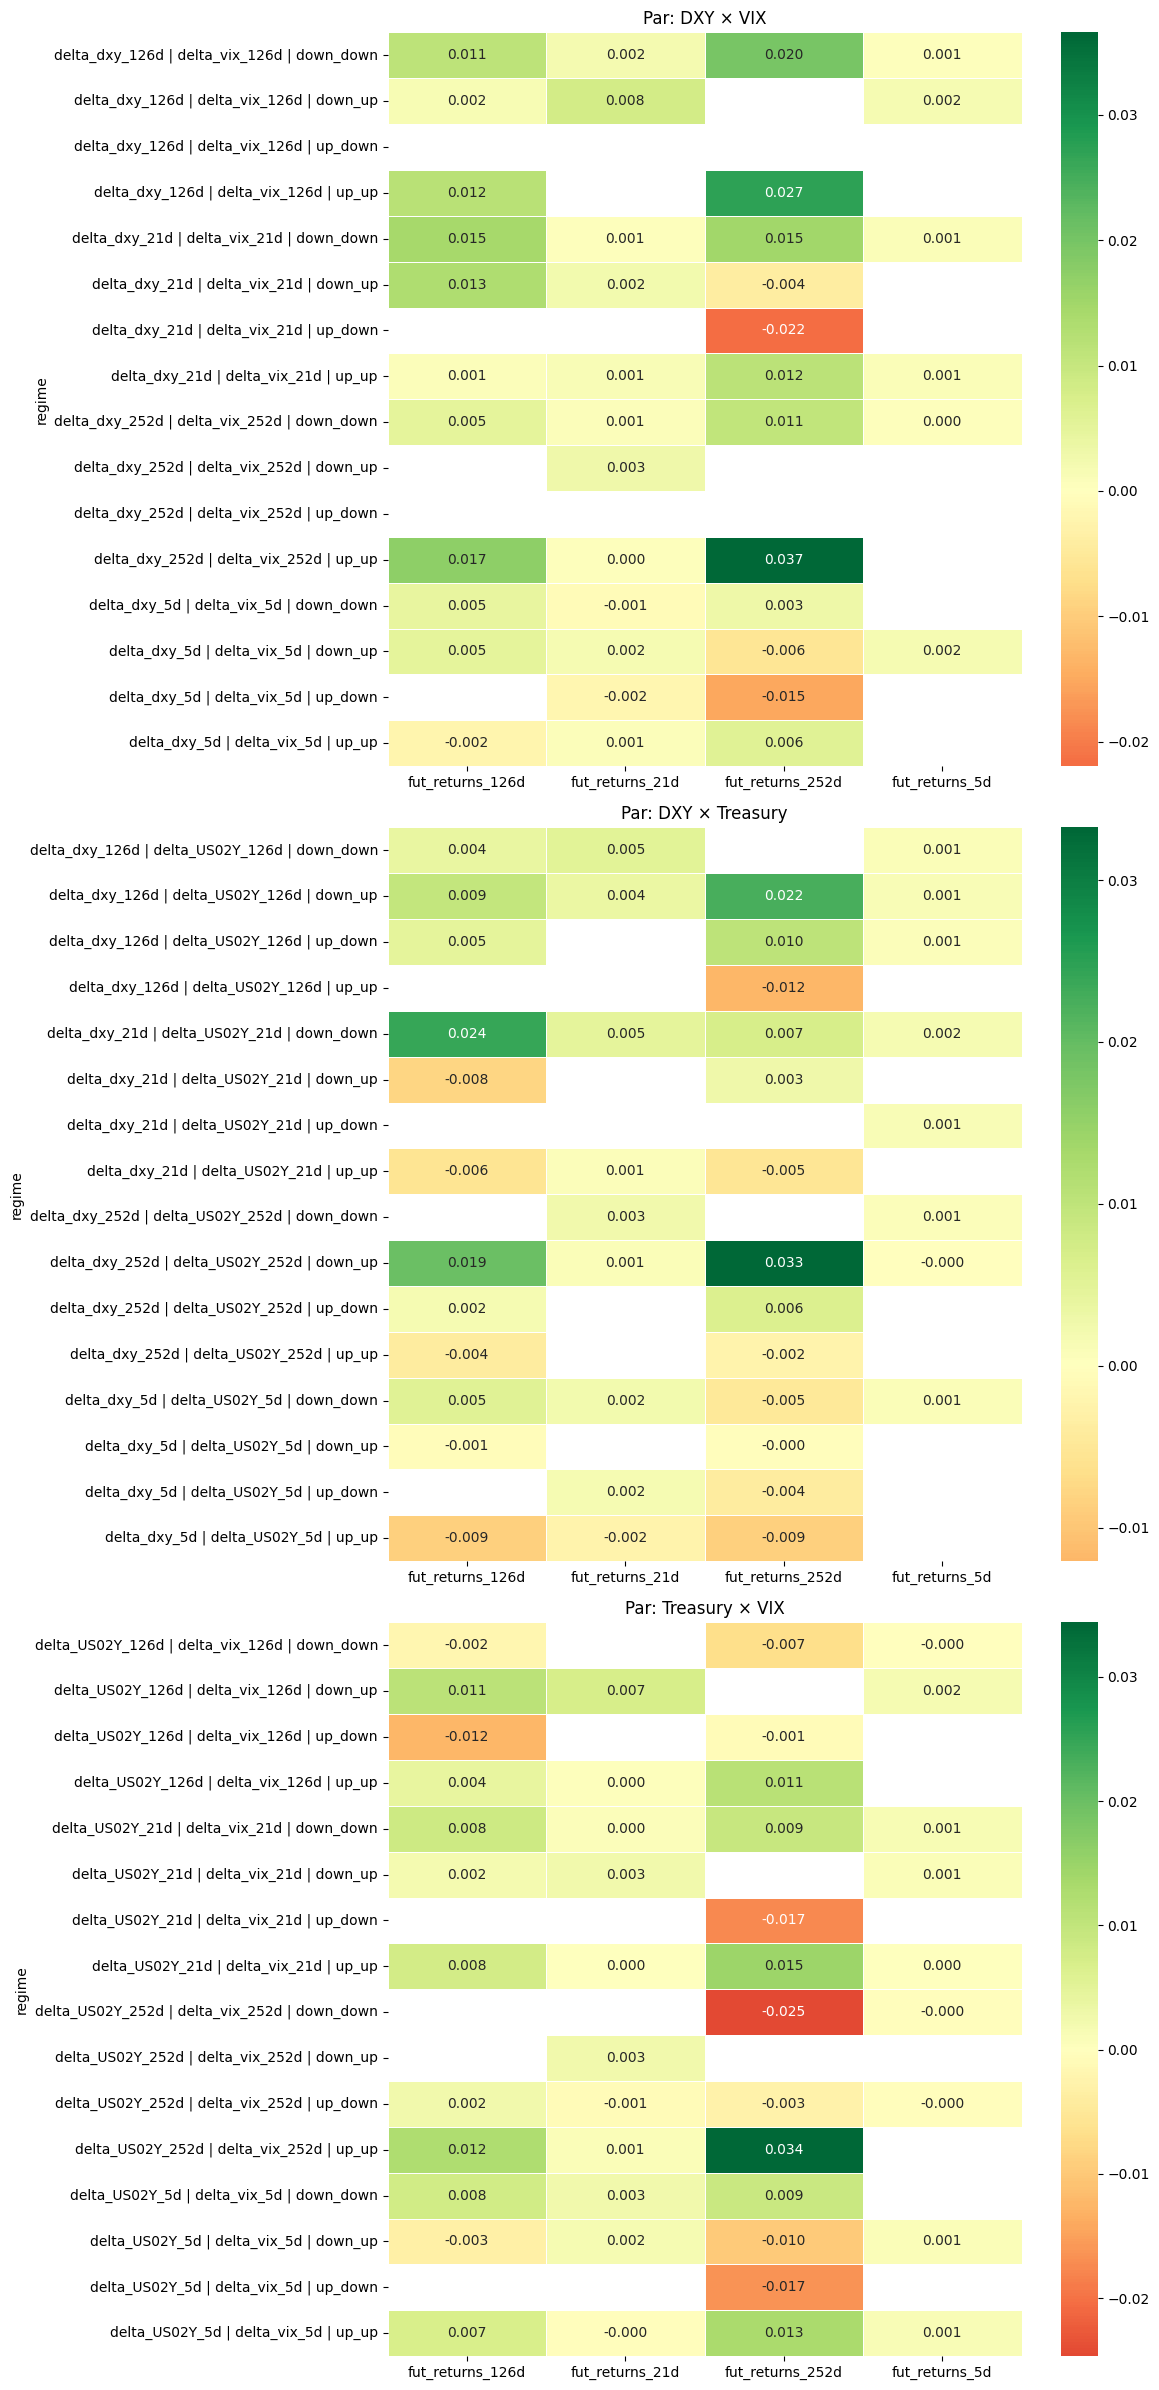

In [19]:
#visualization 

all_results['regime'] = (all_results['var1'] + ' | ' +
                         all_results['var2'] + ' | ' +
                         all_results['quadrant'])

pairs = {
    'DXY × VIX': all_results[
        all_results['var1'].str.contains('dxy') & 
        all_results['var2'].str.contains('vix')
    ],
    'DXY × Treasury': all_results[
        all_results['var1'].str.contains('dxy') & 
        all_results['var2'].str.contains('US02Y')
    ],
    'Treasury × VIX': all_results[
        all_results['var1'].str.contains('US02Y') & 
        all_results['var2'].str.contains('vix')
    ],
}


fig, axes = plt.subplots(3, 1, figsize=(12,24))

for ax, (pair_name, df_pair) in zip(axes, pairs.items()):
    heatmap_data = df_pair.pivot_table(
        index = 'regime',
        columns = df_pair.index,
        values = 'diff_baseline'
    )

    mask = df_pair.pivot_table(
        index = 'regime',
        columns = df_pair.index,
        values = 'significant'
    ).eq(False) #True where it isn't significant

    sns.heatmap(
        heatmap_data,
        mask = mask,
        cmap= 'RdYlGn',
        center = 0,
        annot = True,
        fmt = '.3f',
        linewidths = 0.5,
        ax = ax
    )

    ax.set_title(f'Par: {pair_name}')

#ax.set_title('Diff vs Baseline per Regime and Horizon\n(White cells = not significant)')
plt.tight_layout()
plt.show()

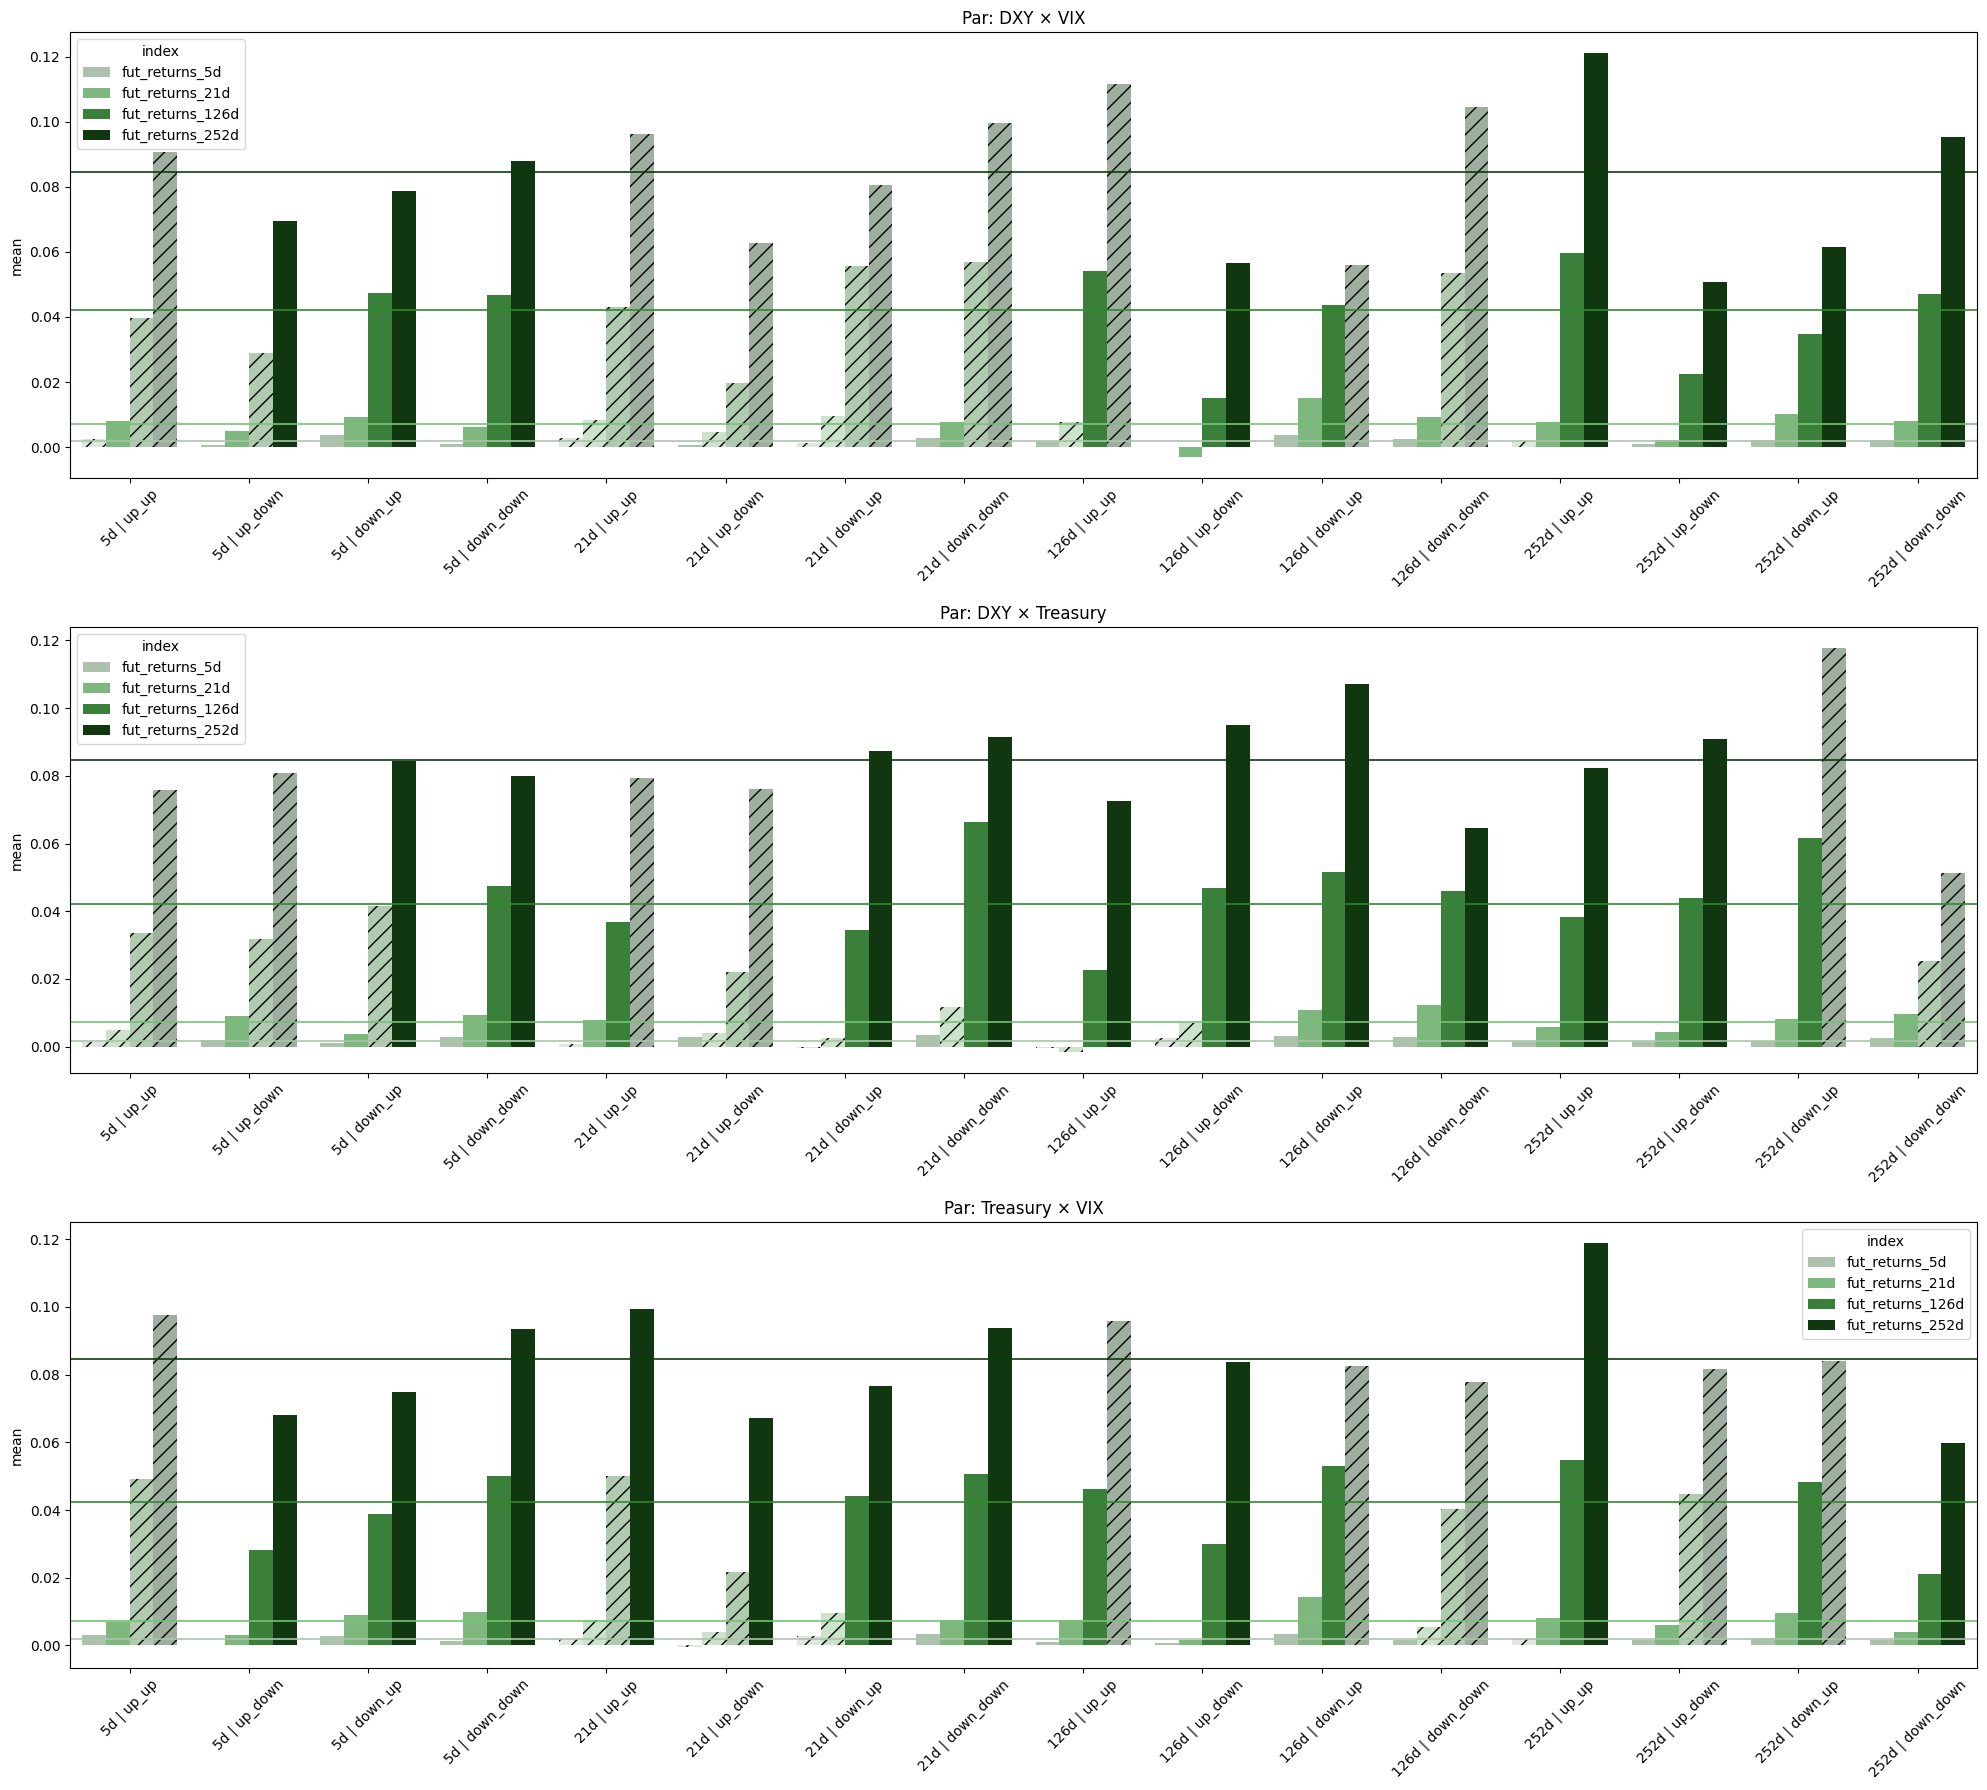

In [ ]:
# cores = {
#     'fut_returns_5d':   '#c6e8c6', 
#     'fut_returns_21d':  '#74c274',  
#     'fut_returns_126d': '#2e8b2e',  
#     'fut_returns_252d': '#0a3d0a',  
# }

fig, axes = plt.subplots(3, 1, figsize=(20, 18))

horizons= ['fut_returns_5d', 'fut_returns_21d', 
              'fut_returns_126d', 'fut_returns_252d']

colors_list = ["#a9c5a9", '#74c274', '#2e8b2e', '#0a3d0a']

for ax, (pair_anme, df_par) in zip(axes, pairs.items()):
    
    # reset index to have horizon as column
    df_plot = df_par.reset_index()
    df_plot = df_plot.rename(columns={'Date': 'horizon'})
       
    df_plot['short_regime'] = (df_plot['var1'].str.extract(r'_(\d+d)')[0] + 
                                ' | ' + df_plot['quadrant'])
    
    sns.barplot(
        data=df_plot,
        x='short_regime',
        y='mean',
        hue='index',
        palette=colors_list,
        ax=ax
    )
    
    # horizons baseline
    baseline_means = {
        'fut_returns_5d':   0.001775,
        'fut_returns_21d':  0.007151,
        'fut_returns_126d': 0.042235,
        'fut_returns_252d': 0.084629
    }
    for horizon, color, baseline in zip(horizons, colors_list, baseline_means.values()):
        ax.axhline(y=baseline, color=color, linestyle='-', linewidth=1.2, alpha=1)
    
    # hatch where it's not significant
    for bar, (_, row) in zip(ax.patches, df_plot.iterrows()):
        if not row['significant']:
            bar.set_hatch('//')
            bar.set_alpha(0.4)
    
    ax.set_title(f'Par: {pair_anme}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

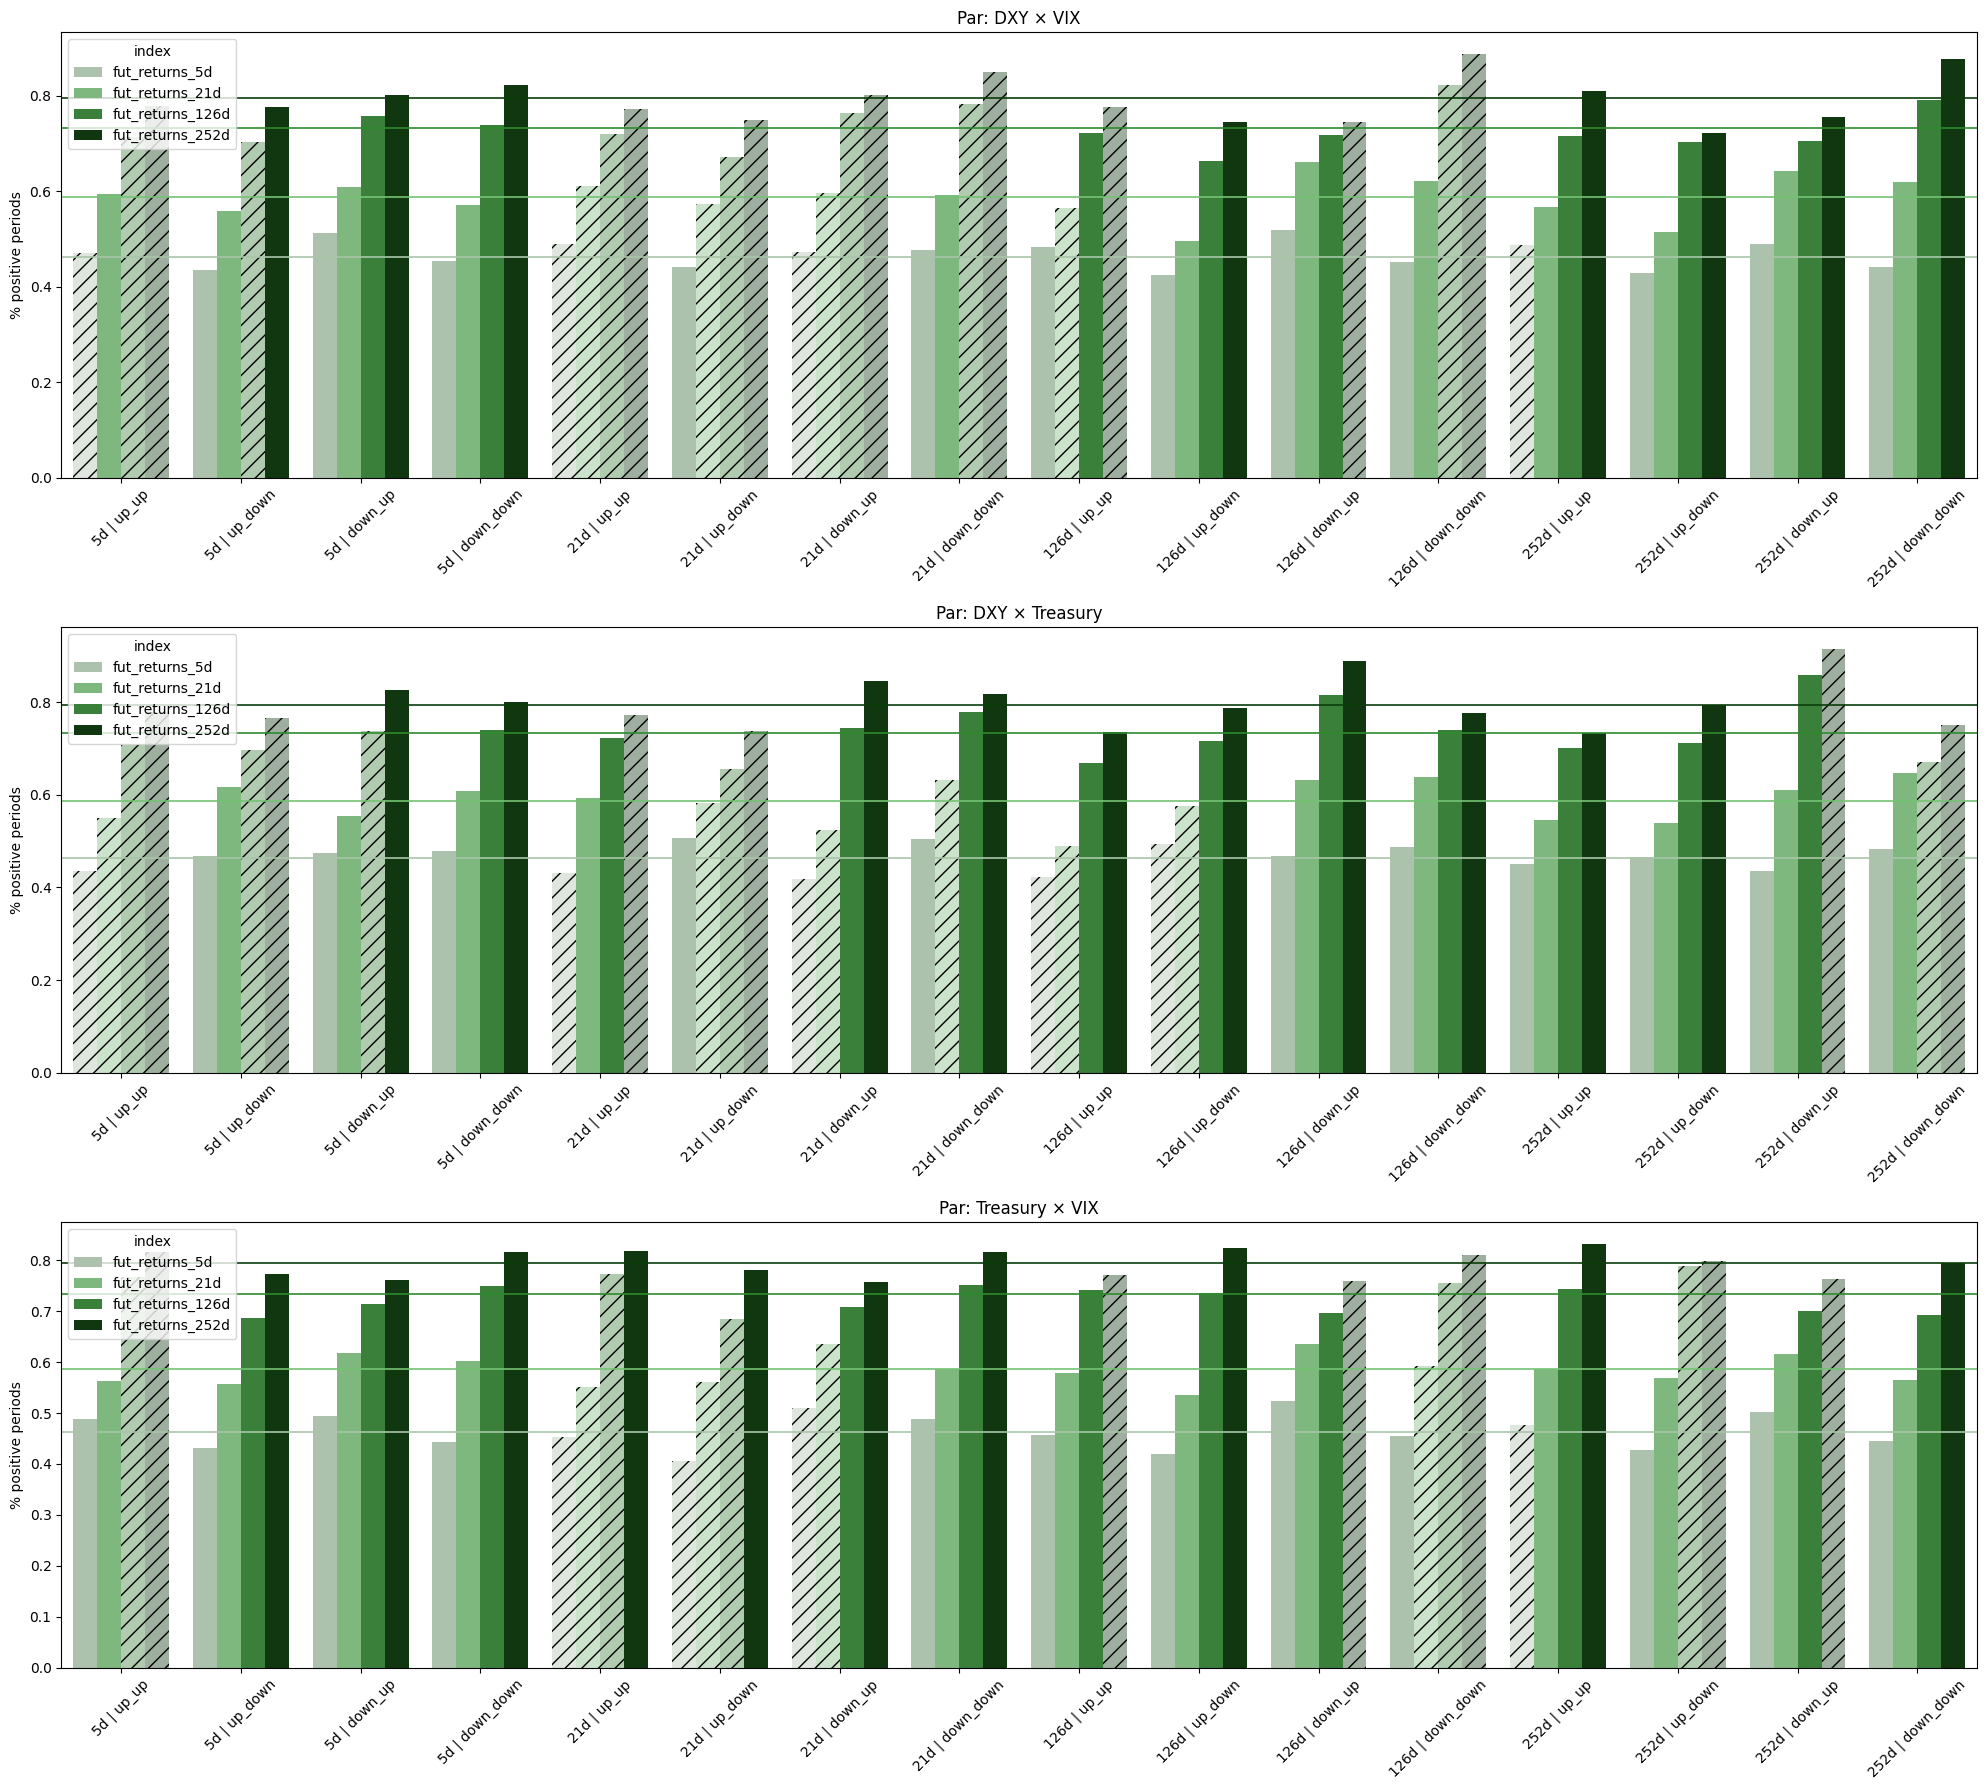

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(20, 18))

horizons= ['fut_returns_5d', 'fut_returns_21d', 
              'fut_returns_126d', 'fut_returns_252d']

colors_list = ["#a9c5a9", '#74c274', '#2e8b2e', '#0a3d0a']

for ax, (pair_anme, df_par) in zip(axes, pairs.items()):
    
    # reset index to have horizon as column
    df_plot = df_par.reset_index()
    df_plot = df_plot.rename(columns={'Date': 'horizon'})  
    
    df_plot['short_regime'] = (df_plot['var1'].str.extract(r'_(\d+d)')[0] + 
                                ' | ' + df_plot['quadrant'])
    
    sns.barplot(
        data=df_plot,
        x='short_regime',
        y='pct_positive',
        hue='index',
        palette=colors_list,
        ax=ax
    )
    
    # horizons positive percentage baseline
    baseline_pct = {
        'fut_returns_5d':   0.462995,
        'fut_returns_21d':  0.586848,
        'fut_returns_126d': 0.733124,
        'fut_returns_252d': 0.794237
    }

    for horizon, color, baseline in zip(horizons, colors_list, baseline_pct.values()):
        ax.axhline(y=baseline, color=color, linestyle='-', linewidth=1.2, alpha=1)
    
    # hatch where it's not significant
    for bar, (_, row) in zip(ax.patches, df_plot.iterrows()):
        if not row['significant']:
            bar.set_hatch('//')
            bar.set_alpha(0.4)
    
    ax.set_title(f'Par: {pair_anme}')
    ax.set_ylabel('% positive periods')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()